# 😴 Human Stress Detection Based on Sleeping Habits
### Final Term Project | SaYoPillow Dataset (IEEE Research)
**Student:** Marium Ahmad

---
## 📋 Project Pipeline:
| Step | Description |
|------|------------|
| 1 | 🧹 Data Cleaning |
| 2 | 📊 Exploratory Data Analysis (EDA) |
| 3 | ⚙️ Feature Engineering & Preprocessing |
| 4 | 🤖 Traditional ML Model Building (7 Models) |
| 5 | 🧠 Deep Learning — ANN from Scratch (NumPy) |
| 6 | 🔬 Deep Learning — CNN from Scratch (NumPy) |
| 7 | 📈 Full Evaluation & Comparison (ML vs DL) |
| 8 | 🚀 Improvement — Voting Classifier + Cross Validation |
| 9 | 🌐 Deployment — Streamlit App |

---
### 📌 About the Dataset (SaYoPillow):
> Real research dataset from **IEEE Transactions on Instrumentation and Measurement**  
> Monitors physiological signals during sleep to detect stress levels.

| Column | Meaning |
|--------|---------|
| sr | Snoring Rate (%) |
| rr | Respiration Rate |
| t | Body Temperature (°F) |
| lm | Limb Movement Rate |
| bo | Blood Oxygen Level (%) |
| rem | REM Sleep (%) |
| sr.1 | Sleep Hours |
| hr | Heart Rate (BPM) |
| sl | **Stress Level** (0=Low → 4=High) ← Target |

## 📦 Import All Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report,
                              precision_score, recall_score, f1_score)

print("✅ All libraries imported successfully!")

---
## Step 1: 🧹 Data Cleaning
> Load the dataset, rename columns, check for missing values and duplicates.

In [ ]:
df = pd.read_csv('SaYoPillow.csv')
print(f"📂 Dataset loaded! Shape: {df.shape}")
df.head(10)

In [ ]:
df.rename(columns={
    'sr'  : 'snoring_rate',
    'rr'  : 'respiration_rate',
    't'   : 'body_temperature',
    'lm'  : 'limb_movement',
    'bo'  : 'blood_oxygen',
    'rem' : 'rem_sleep',
    'sr.1': 'sleep_hours',
    'hr'  : 'heart_rate',
    'sl'  : 'stress_level'
}, inplace=True)
print("✅ Columns renamed!")
df.head()

In [ ]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"✅ Shape after cleaning: {df.shape}")

In [ ]:
stress_labels = {0:'Low', 1:'Low-Medium', 2:'Medium', 3:'Medium-High', 4:'High'}
print("Stress Level Distribution:")
print(df['stress_level'].value_counts().sort_index())
print("\nStress Level Meaning:")
for k,v in stress_labels.items():
    print(f"  {k} = {v}")

In [ ]:
df.describe().round(2)

---
## Step 2: 📊 Exploratory Data Analysis (EDA)
> Visualize data to understand distributions and feature relationships.

In [ ]:
colors = ['#2196F3','#4CAF50','#FF9800','#FF5722','#F44336']
stress_labels = {0:'Low', 1:'Low-Med', 2:'Medium', 3:'Med-High', 4:'High'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = sns.countplot(x='stress_level', data=df, palette=colors, ax=axes[0])
ax.set_xticklabels([stress_labels[i] for i in range(5)])
ax.set_title('Stress Level Distribution', fontsize=13, fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2, p.get_height()+1), ha='center')
df['stress_level'].value_counts().sort_index().plot(
    kind='pie', labels=[stress_labels[i] for i in range(5)],
    autopct='%1.1f%%', colors=colors, startangle=90, ax=axes[1])
axes[1].set_title('Stress Level Proportions', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

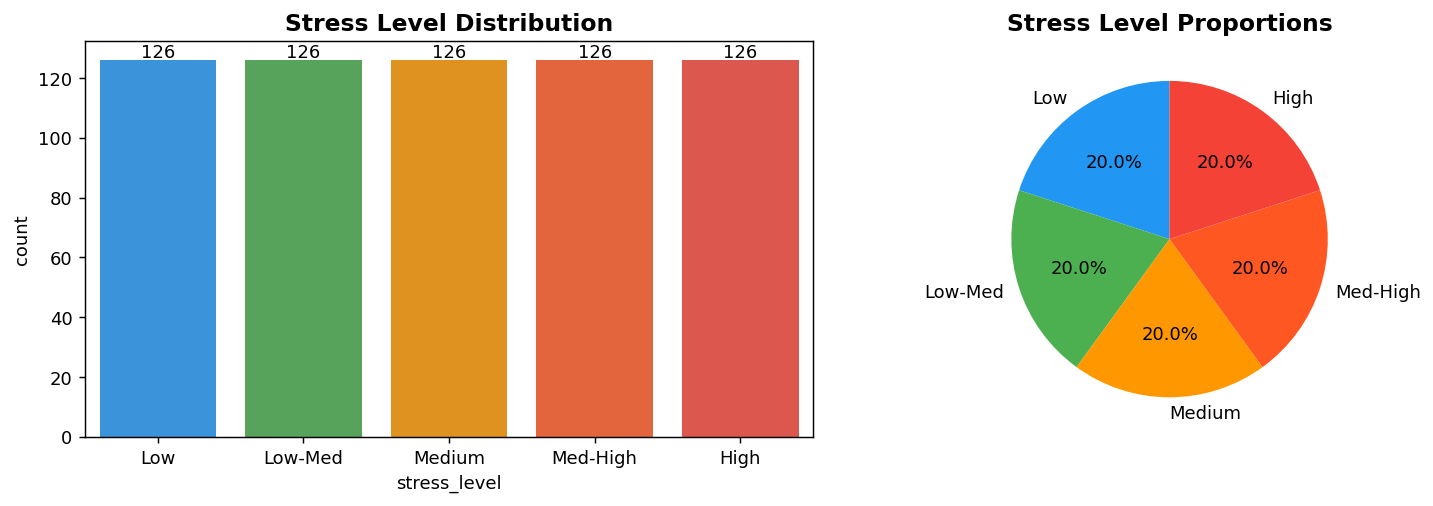

In [ ]:
# Figure displayed below

In [ ]:
features = ['snoring_rate','respiration_rate','body_temperature','limb_movement',
            'blood_oxygen','rem_sleep','sleep_hours','heart_rate']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    sns.boxplot(x='stress_level', y=feat, data=df, palette=colors, ax=axes[i])
    axes[i].set_title(feat.replace('_',' ').title(), fontsize=10)
    axes[i].set_xticklabels(['Low','L-M','Med','M-H','High'], fontsize=7)
plt.suptitle('Feature Distribution Across Stress Levels', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

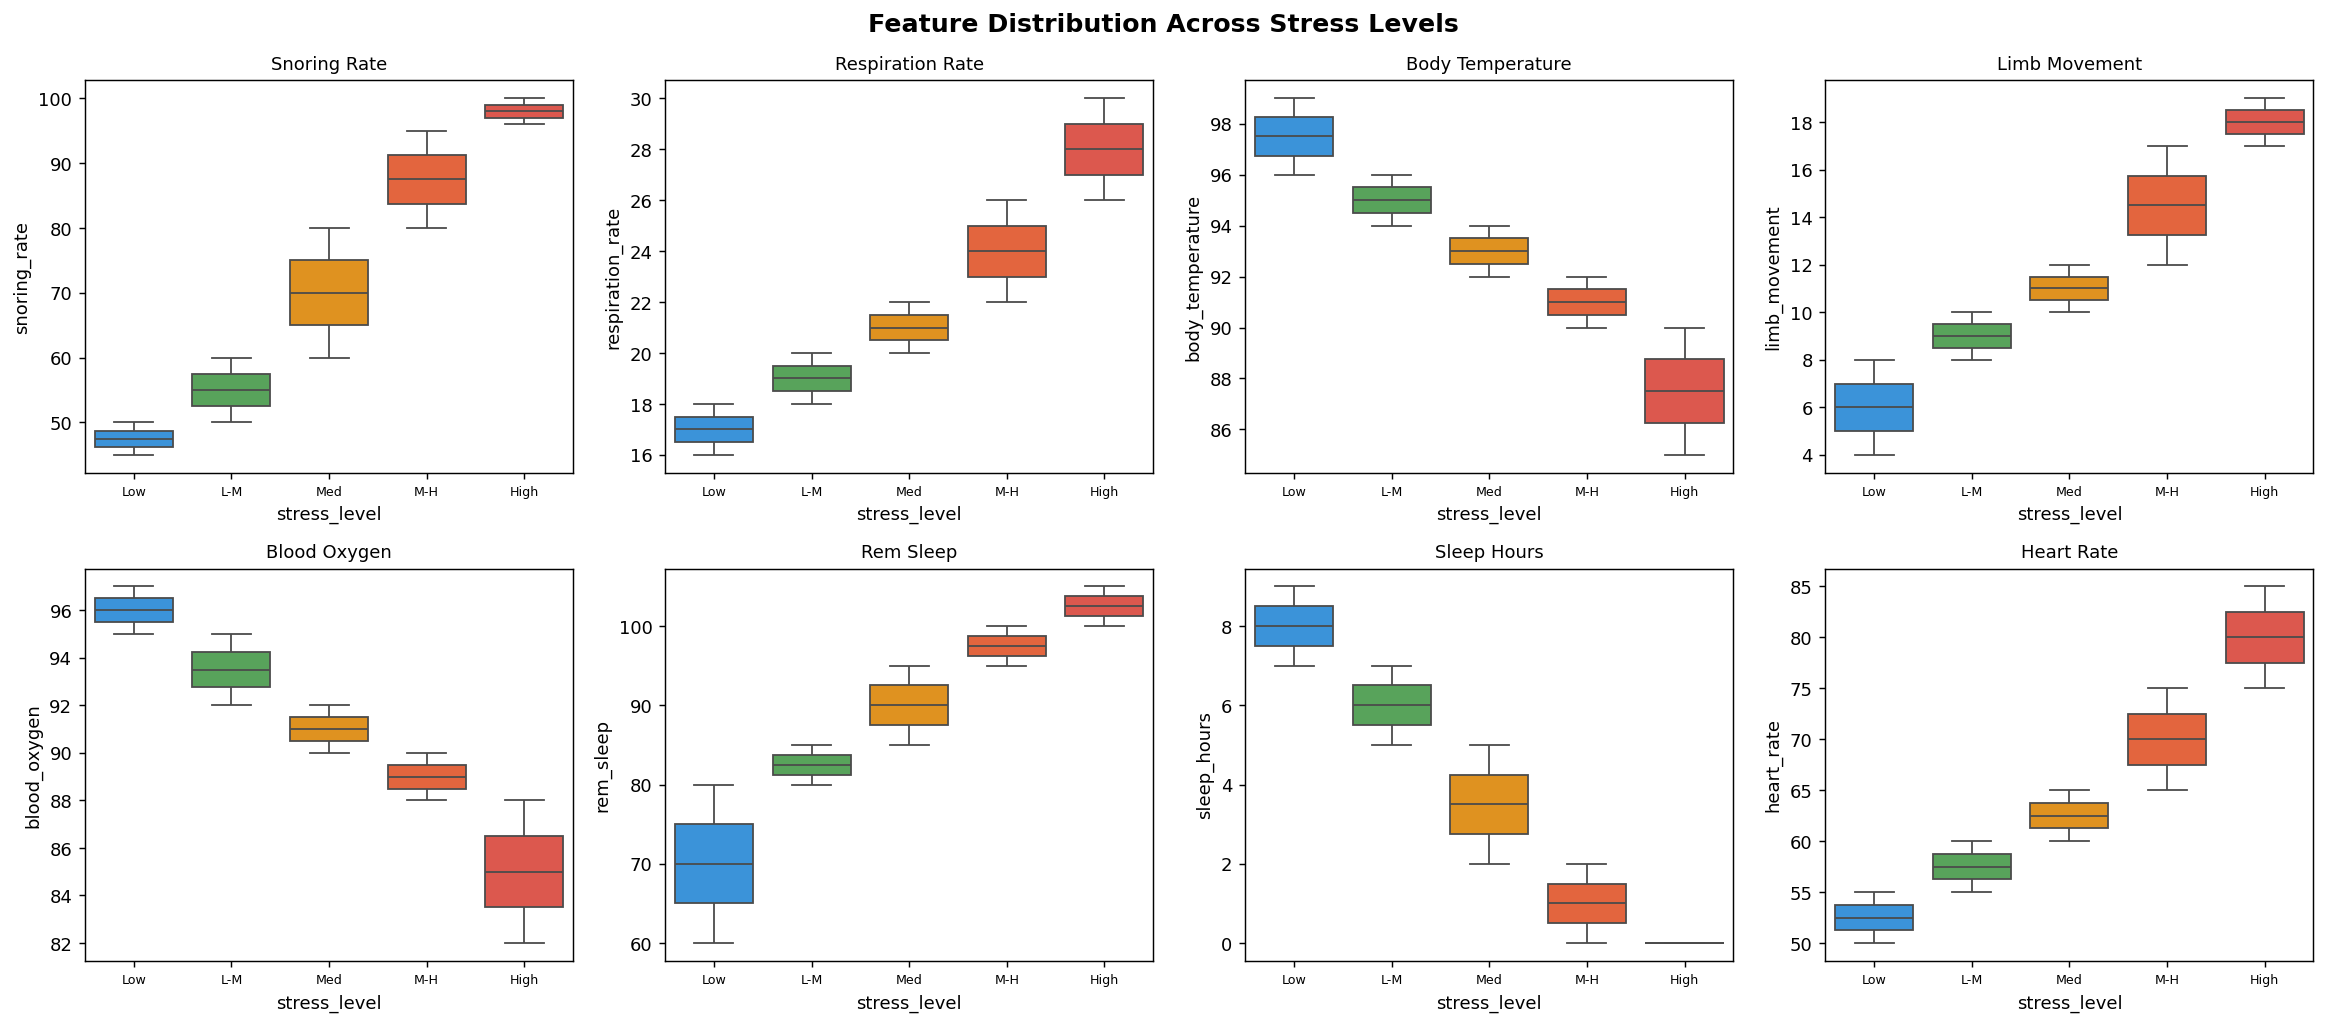

In [ ]:
# Figure displayed below

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

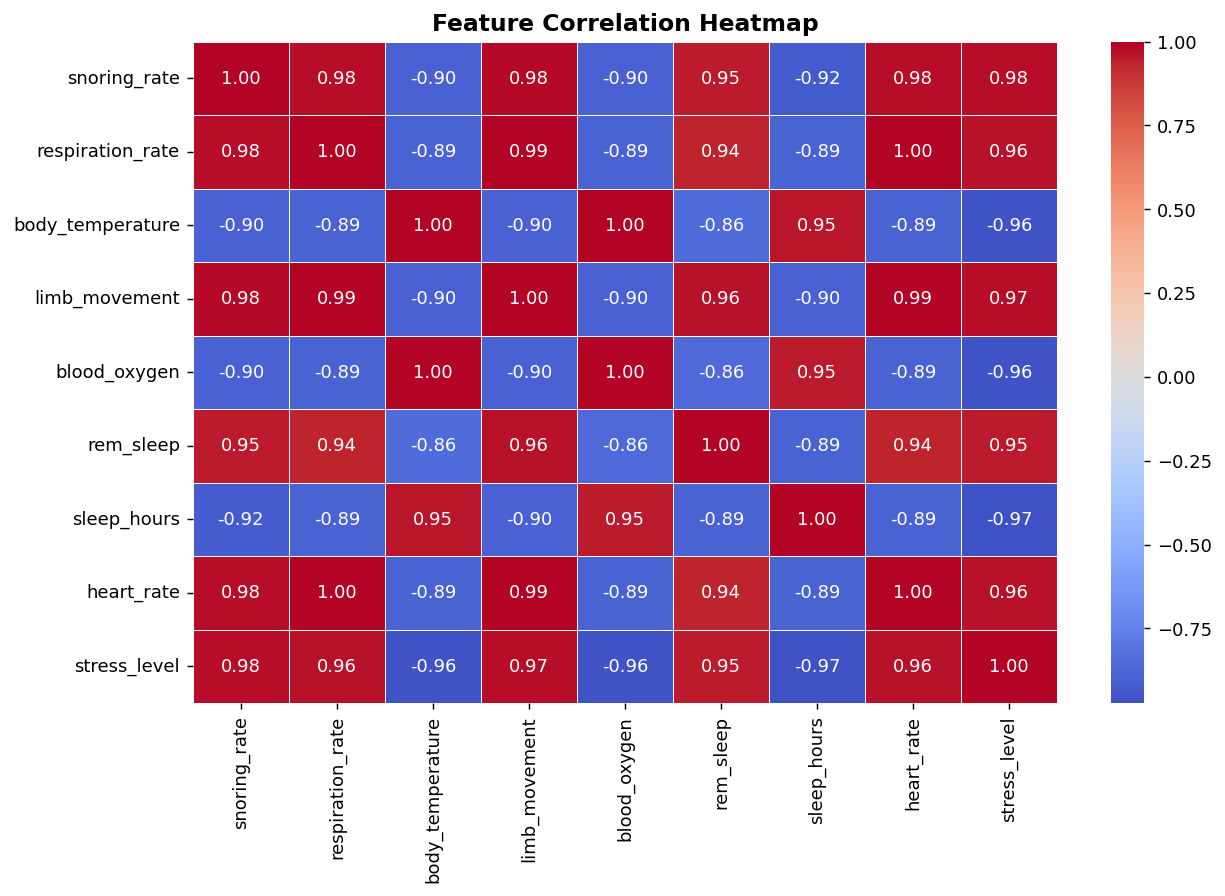

In [ ]:
# Figure displayed below

---
## Step 3: ⚙️ Feature Engineering & Preprocessing
> Create 3 new meaningful features, then scale and split the data.

In [ ]:
df['oxygen_heart_ratio']  = (df['blood_oxygen'] / df['heart_rate']).round(3)
df['sleep_quality_score'] = (df['rem_sleep'] * df['sleep_hours']).round(3)
df['stress_indicator']    = (df['snoring_rate'] + df['limb_movement'] +
                              df['respiration_rate']).round(3)

print("✅ New features created!")
df[['oxygen_heart_ratio','sleep_quality_score','stress_indicator','stress_level']].head(8)

In [ ]:
X = df.drop(columns=['stress_level'])
y = df['stress_level'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Features  : {list(X.columns)}")
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("✅ Data scaled and ready!")

---
## Step 4: 🤖 Traditional ML Model Building
> Train 7 different classic ML models for multi-class classification (5 stress levels).

In [ ]:
ml_models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                  : SVC(kernel='rbf', random_state=42),
    'KNN'                  : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'          : GaussianNB(),
}

results = {}
for name, model in ml_models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred)*100, 2),
        'Precision': round(precision_score(y_test, y_pred, average='weighted')*100, 2),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted')*100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred, average='weighted')*100, 2),
    }
    print(f"✅ {name}: {results[name]['Accuracy']}%")

print("\n🎉 All 7 ML models trained!")
pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)

---
## Step 5: 🧠 Deep Learning — ANN Built from Scratch (NumPy)

### What is an ANN?
An **Artificial Neural Network** is a system inspired by the human brain.  
It consists of layers of "neurons" connected by weights.

**Our ANN architecture:**
- **Input Layer:** 11 features (8 original + 3 engineered)
- **Hidden Layer 1:** 128 neurons — ReLU activation
- **Hidden Layer 2:** 64 neurons — ReLU activation  
- **Hidden Layer 3:** 32 neurons — ReLU activation
- **Output Layer:** 5 neurons — Softmax (one per stress class)

**Key concepts used:**
- **Forward Propagation** — compute predictions
- **Backpropagation** — compute gradients and update weights
- **ReLU** — activation function that avoids vanishing gradients
- **Softmax** — converts output to class probabilities
- **Mini-batch Gradient Descent** — efficient weight updates

In [ ]:
class ANN:
    """
    Artificial Neural Network built from scratch using NumPy only.
    Architecture: Input → 128 → 64 → 32 → 5 (Output)
    Activations : ReLU (hidden) | Softmax (output)
    Optimizer   : Mini-batch Gradient Descent
    """
    def __init__(self, layer_sizes, lr=0.005):
        self.lr = lr
        self.W, self.b = [], []
        np.random.seed(42)
        for i in range(len(layer_sizes)-1):
            # He initialization for ReLU layers
            self.W.append(np.random.randn(layer_sizes[i], layer_sizes[i+1])
                          * np.sqrt(2 / layer_sizes[i]))
            self.b.append(np.zeros((1, layer_sizes[i+1])))

    # ── Activation functions ──────────────────────────────────────────────
    def relu(self, z):
        """Rectified Linear Unit — outputs 0 for negatives, z for positives"""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Gradient of ReLU — 1 if z>0, else 0"""
        return (z > 0).astype(float)

    def softmax(self, z):
        """Converts raw scores to probabilities that sum to 1"""
        e = np.exp(z - z.max(axis=1, keepdims=True))   # numerical stability
        return e / e.sum(axis=1, keepdims=True)

    def one_hot(self, y, n_classes):
        oh = np.zeros((len(y), n_classes))
        oh[np.arange(len(y)), y] = 1
        return oh

    # ── Forward Propagation ───────────────────────────────────────────────
    def forward(self, X):
        """Pass input through each layer to get predictions"""
        self.A = [X]        # activations
        self.Z = []         # pre-activation values
        for i in range(len(self.W)-1):          # hidden layers
            z = self.A[-1] @ self.W[i] + self.b[i]
            self.Z.append(z)
            self.A.append(self.relu(z))
        z = self.A[-1] @ self.W[-1] + self.b[-1]  # output layer
        self.Z.append(z)
        self.A.append(self.softmax(z))
        return self.A[-1]

    # ── Backpropagation ───────────────────────────────────────────────────
    def backward(self, y_oh):
        """Compute gradients and update weights using chain rule"""
        m = len(y_oh)
        dA = self.A[-1] - y_oh              # output layer gradient
        for i in reversed(range(len(self.W))):
            dW = self.A[i].T @ dA / m
            db = dA.mean(axis=0, keepdims=True)
            if i > 0:
                dA = (dA @ self.W[i].T) * self.relu_derivative(self.Z[i-1])
            self.W[i] -= self.lr * dW       # update weights
            self.b[i] -= self.lr * db       # update biases

    def fit(self, X, y, epochs=300, batch_size=32):
        n_classes = len(np.unique(y))
        y_oh = self.one_hot(y, n_classes)
        self.losses = []
        for ep in range(epochs):
            idx = np.random.permutation(len(X))
            X, y_oh = X[idx], y_oh[idx]
            for s in range(0, len(X), batch_size):
                Xb, yb = X[s:s+batch_size], y_oh[s:s+batch_size]
                self.forward(Xb)
                self.backward(yb)
            out  = self.forward(X)
            loss = -np.mean(y_oh * np.log(out + 1e-9))
            self.losses.append(loss)
            if (ep+1) % 50 == 0:
                print(f"  Epoch {ep+1:3d} | Loss: {loss:.4f}")
        return self.losses

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

# Train ANN
print("🧠 Training ANN...")
ann = ANN([X_train_s.shape[1], 128, 64, 32, 5], lr=0.005)
ann.fit(X_train_s, y_train, epochs=300)
ann_pred = ann.predict(X_test_s)
ann_acc  = accuracy_score(y_test, ann_pred) * 100
print(f"\n✅ ANN Test Accuracy: {ann_acc:.2f}%")

In [ ]:
# ANN Architecture Diagram
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
layer_info = [('Input\n(11 features)', 11, 0.8),
              ('Hidden 1\n128 neurons', 8, 2.8),
              ('Hidden 2\n64 neurons', 6, 4.8),
              ('Hidden 3\n32 neurons', 4, 6.8),
              ('Output\n5 classes', 5, 8.8)]
layer_cols = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
all_ys = []
for idx, (lbl, n_show, x) in enumerate(layer_info):
    n = min(n_show, 8)
    ys = np.linspace(1.5, 8.5, n)
    all_ys.append((ys, x))
    for y in ys:
        circle = plt.Circle((x, y), 0.28, color=layer_cols[idx], zorder=3, alpha=0.9)
        ax.add_patch(circle)
    ax.text(x, 0.6, lbl, ha='center', fontsize=9, fontweight='bold', color=layer_cols[idx])
for i in range(len(all_ys)-1):
    for y1 in all_ys[i][0]:
        for y2 in all_ys[i+1][0]:
            ax.plot([all_ys[i][1]+0.28, all_ys[i+1][1]-0.28],[y1, y2],
                    'gray', alpha=0.07, linewidth=0.4, zorder=1)
ax.text(5, 9.5, 'ANN Architecture: Input → 128 → 64 → 32 → Output  |  ReLU + Softmax + Mini-batch GD',
        ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

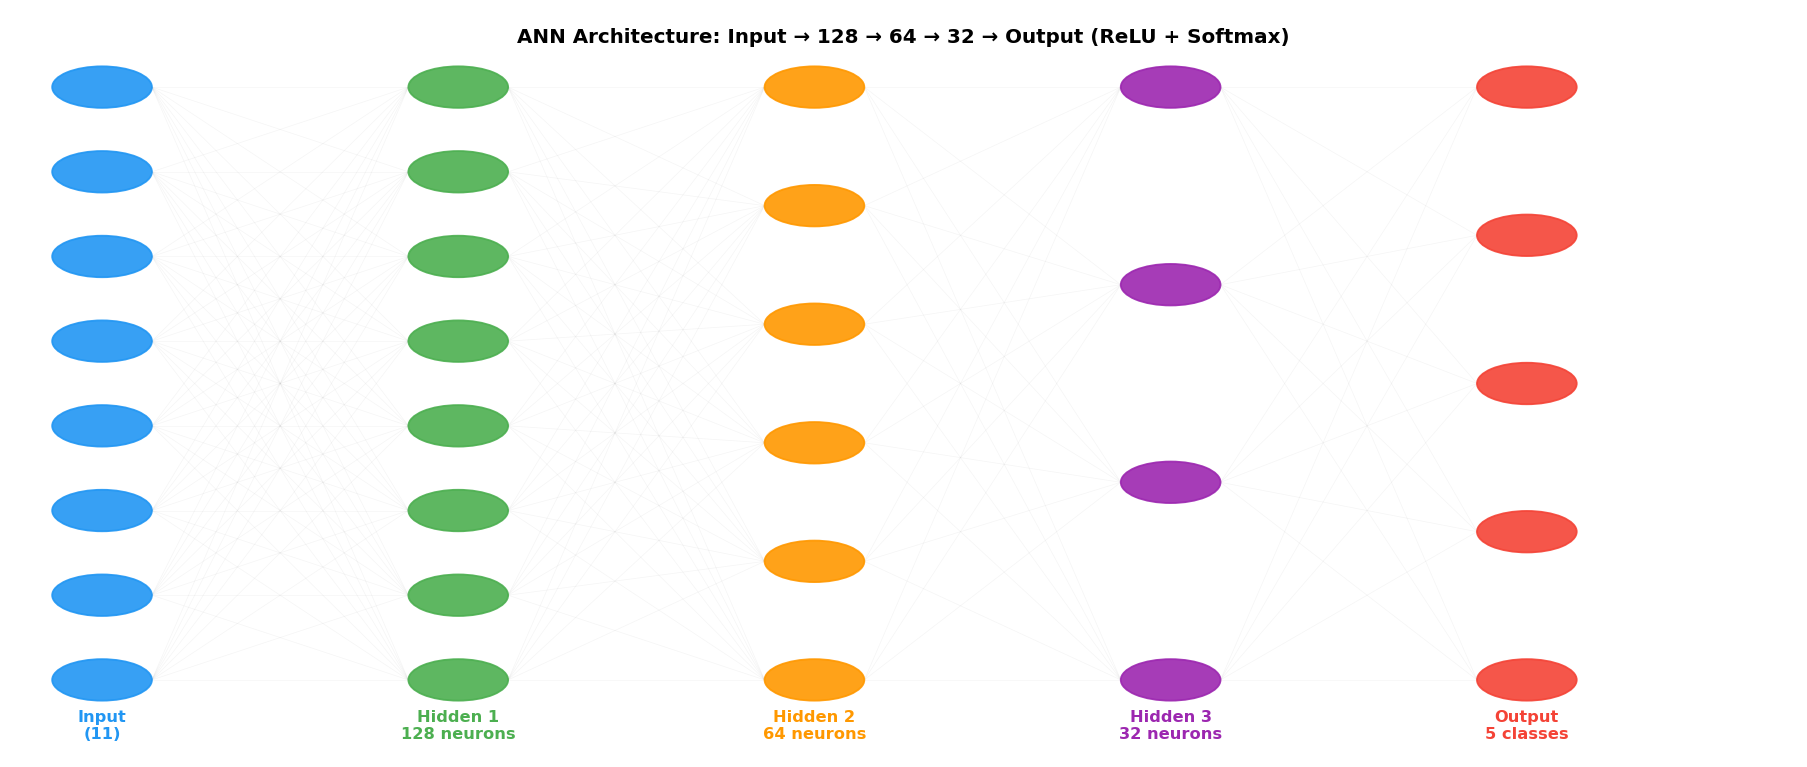

In [ ]:
# Figure displayed below

In [ ]:
# ANN Training Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(ann.losses, color='#2196F3', linewidth=2)
plt.title('ANN Training Loss (Cross-Entropy)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("📌 Loss decreasing = ANN is learning correctly!")

---
## Step 6: 🔬 Deep Learning — CNN Built from Scratch (NumPy)

### What is a CNN for tabular data?
A **Convolutional Neural Network** uses filters (kernels) that slide over data  
to detect **local patterns**. For tabular/sensor data, we treat the 11 features  
as a **1D signal** — each kernel finds patterns between neighboring features.

**Why CNN for sensor data?**  
Sleep physiological signals are sequential and correlated —  
snoring rate, respiration rate, limb movement happen together.  
A 1D CNN can capture these **local correlations** better than a plain ANN.

**Our CNN architecture:**
- **Conv1D Layer:** 16 filters, kernel size 3 → detects 3-feature patterns
- **ReLU** activation
- **Flatten** → convert feature maps to 1D
- **Fully Connected:** 64 neurons (ReLU)
- **Output:** 5 neurons (Softmax)

In [ ]:
class CNN1D:
    """
    1-D Convolutional Neural Network built from scratch using NumPy.
    Treats 11 tabular features as a 1-D signal and applies conv filters.
    Architecture: Conv1D(16 filters, k=3) → ReLU → Flatten → FC(64) → Output(5)
    """
    def __init__(self, n_features, n_filters=16, kernel=3, lr=0.005):
        np.random.seed(42)
        self.lr, self.k, self.n_filters = lr, kernel, n_filters
        self.n_features = n_features
        self.conv_out_len = n_features - kernel + 1   # length after conv
        # Conv weights: (n_filters, kernel_size)
        self.W_conv = np.random.randn(n_filters, kernel) * 0.1
        self.b_conv = np.zeros(n_filters)
        # Fully connected weights
        fc_in = n_filters * self.conv_out_len
        self.W_fc1 = np.random.randn(fc_in, 64) * np.sqrt(2/fc_in)
        self.b_fc1 = np.zeros(64)
        self.W_fc2 = np.random.randn(64, 5) * np.sqrt(2/64)
        self.b_fc2 = np.zeros(5)

    def relu(self, z):         return np.maximum(0, z)
    def relu_d(self, z):       return (z > 0).astype(float)
    def softmax(self, z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)
    def one_hot(self, y, n):
        oh = np.zeros((len(y), n)); oh[np.arange(len(y)), y] = 1; return oh

    def conv_forward(self, X):
        """Slide each filter over the 1D feature vector"""
        m = X.shape[0]
        out = np.zeros((m, self.n_filters, self.conv_out_len))
        for f in range(self.n_filters):
            for j in range(self.conv_out_len):
                # dot product of filter with window of size k
                out[:, f, j] = X[:, j:j+self.k] @ self.W_conv[f] + self.b_conv[f]
        return out

    def forward(self, X):
        self.X_in     = X
        self.conv_out = self.conv_forward(X)          # (m, filters, L)
        self.conv_act = self.relu(self.conv_out)      # apply ReLU
        m = X.shape[0]
        self.flat = self.conv_act.reshape(m, -1)      # Flatten
        self.z1   = self.flat @ self.W_fc1 + self.b_fc1
        self.a1   = self.relu(self.z1)
        self.z2   = self.a1  @ self.W_fc2 + self.b_fc2
        self.out  = self.softmax(self.z2)
        return self.out

    def backward(self, y_oh):
        m = len(y_oh)
        dz2 = (self.out - y_oh) / m
        self.W_fc2 -= self.lr * self.a1.T @ dz2
        self.b_fc2 -= self.lr * dz2.sum(axis=0)
        da1 = dz2 @ self.W_fc2.T * self.relu_d(self.z1)
        self.W_fc1 -= self.lr * self.flat.T @ da1
        self.b_fc1 -= self.lr * da1.sum(axis=0)
        d_flat    = da1 @ self.W_fc1.T
        d_conv_act = d_flat.reshape(self.conv_act.shape) * self.relu_d(self.conv_out)
        for f in range(self.n_filters):
            for j in range(self.conv_out_len):
                self.W_conv[f] -= self.lr * (self.X_in[:, j:j+self.k].T @ d_conv_act[:, f, j]) / m
            self.b_conv[f] -= self.lr * d_conv_act[:, f, :].mean()

    def fit(self, X, y, epochs=300, batch_size=32):
        y_oh = self.one_hot(y, 5)
        self.losses = []
        for ep in range(epochs):
            idx  = np.random.permutation(len(X))
            Xs, ys = X[idx], y_oh[idx]
            for s in range(0, len(Xs), batch_size):
                self.forward(Xs[s:s+batch_size])
                self.backward(ys[s:s+batch_size])
            out  = self.forward(X)
            loss = -np.mean(y_oh * np.log(out + 1e-9))
            self.losses.append(loss)
            if (ep+1) % 50 == 0:
                print(f"  Epoch {ep+1:3d} | Loss: {loss:.4f}")
        return self.losses

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

# Train CNN
print("🔬 Training CNN...")
cnn = CNN1D(n_features=X_train_s.shape[1], n_filters=16, kernel=3, lr=0.005)
cnn.fit(X_train_s, y_train, epochs=300)
cnn_pred = cnn.predict(X_test_s)
cnn_acc  = accuracy_score(y_test, cnn_pred) * 100
print(f"\n✅ CNN Test Accuracy: {cnn_acc:.2f}%")

In [ ]:
# CNN Training Loss
plt.figure(figsize=(8, 4))
plt.plot(cnn.losses, color='#FF5722', linewidth=2)
plt.title('CNN Training Loss (Cross-Entropy)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

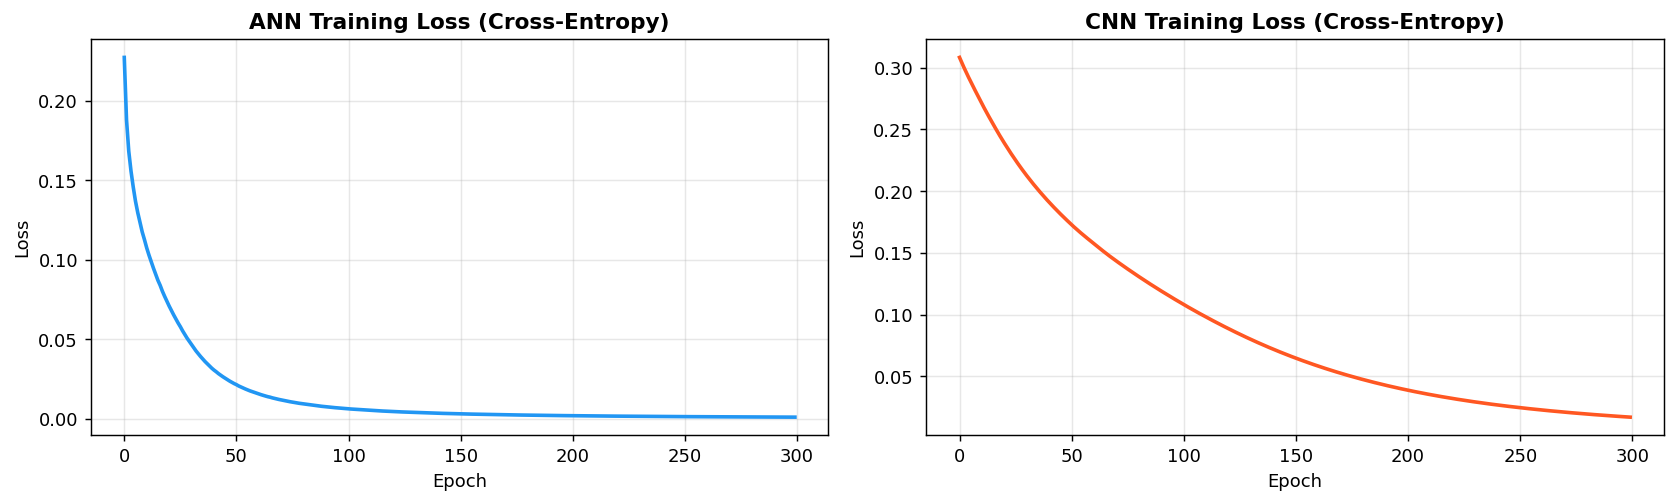

In [ ]:
# Figure displayed below

---
## Step 7: 📈 Full Evaluation & Comparison (Traditional ML vs Deep Learning)

In [ ]:
# Confusion matrices for ANN and CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Low','L-Med','Med','M-High','High']
for ax_i, (pred, title, cmap) in enumerate([
        (ann_pred, 'ANN — Confusion Matrix', 'Blues'),
        (cnn_pred, 'CNN — Confusion Matrix', 'Oranges')]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=axes[ax_i])
    axes[ax_i].set_title(title, fontsize=12, fontweight='bold')
    axes[ax_i].set_ylabel('Actual'); axes[ax_i].set_xlabel('Predicted')
plt.tight_layout(); plt.show()

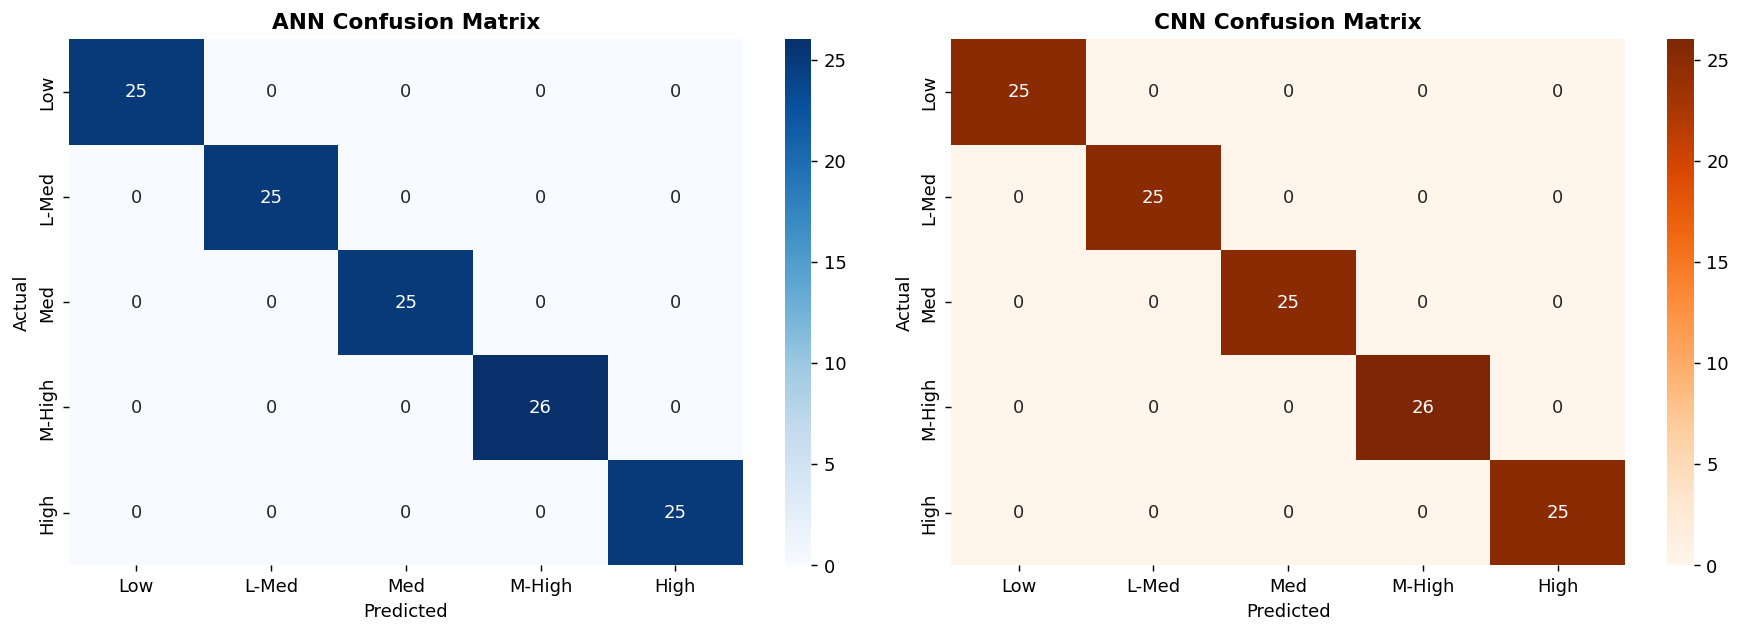

In [ ]:
# Figure displayed below

In [ ]:
# All models comparison table
ann_scores = {
    'Accuracy' : round(accuracy_score(y_test, ann_pred)*100, 2),
    'Precision': round(precision_score(y_test, ann_pred, average='weighted')*100, 2),
    'Recall'   : round(recall_score(y_test, ann_pred, average='weighted')*100, 2),
    'F1 Score' : round(f1_score(y_test, ann_pred, average='weighted')*100, 2),
}
cnn_scores = {
    'Accuracy' : round(accuracy_score(y_test, cnn_pred)*100, 2),
    'Precision': round(precision_score(y_test, cnn_pred, average='weighted')*100, 2),
    'Recall'   : round(recall_score(y_test, cnn_pred, average='weighted')*100, 2),
    'F1 Score' : round(f1_score(y_test, cnn_pred, average='weighted')*100, 2),
}

all_results = {**results,
               '⭐ ANN (Deep Learning)': ann_scores,
               '⭐ CNN (Deep Learning)': cnn_scores}
res_df = pd.DataFrame(all_results).T.sort_values('Accuracy', ascending=False)
print("📊 Full Model Comparison (scores in %):")
res_df

In [ ]:
# Bar chart: all models
sorted_df = res_df.sort_values('Accuracy', ascending=True)
bar_colors = ['#F44336' if '⭐' in n else '#2196F3' for n in sorted_df.index]
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(sorted_df.index, sorted_df['Accuracy'],
               color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, sorted_df['Accuracy']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('All Models Comparison\n🔵 Traditional ML   🔴 Deep Learning', fontsize=13, fontweight='bold')
ax.set_xlim(0, 112); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

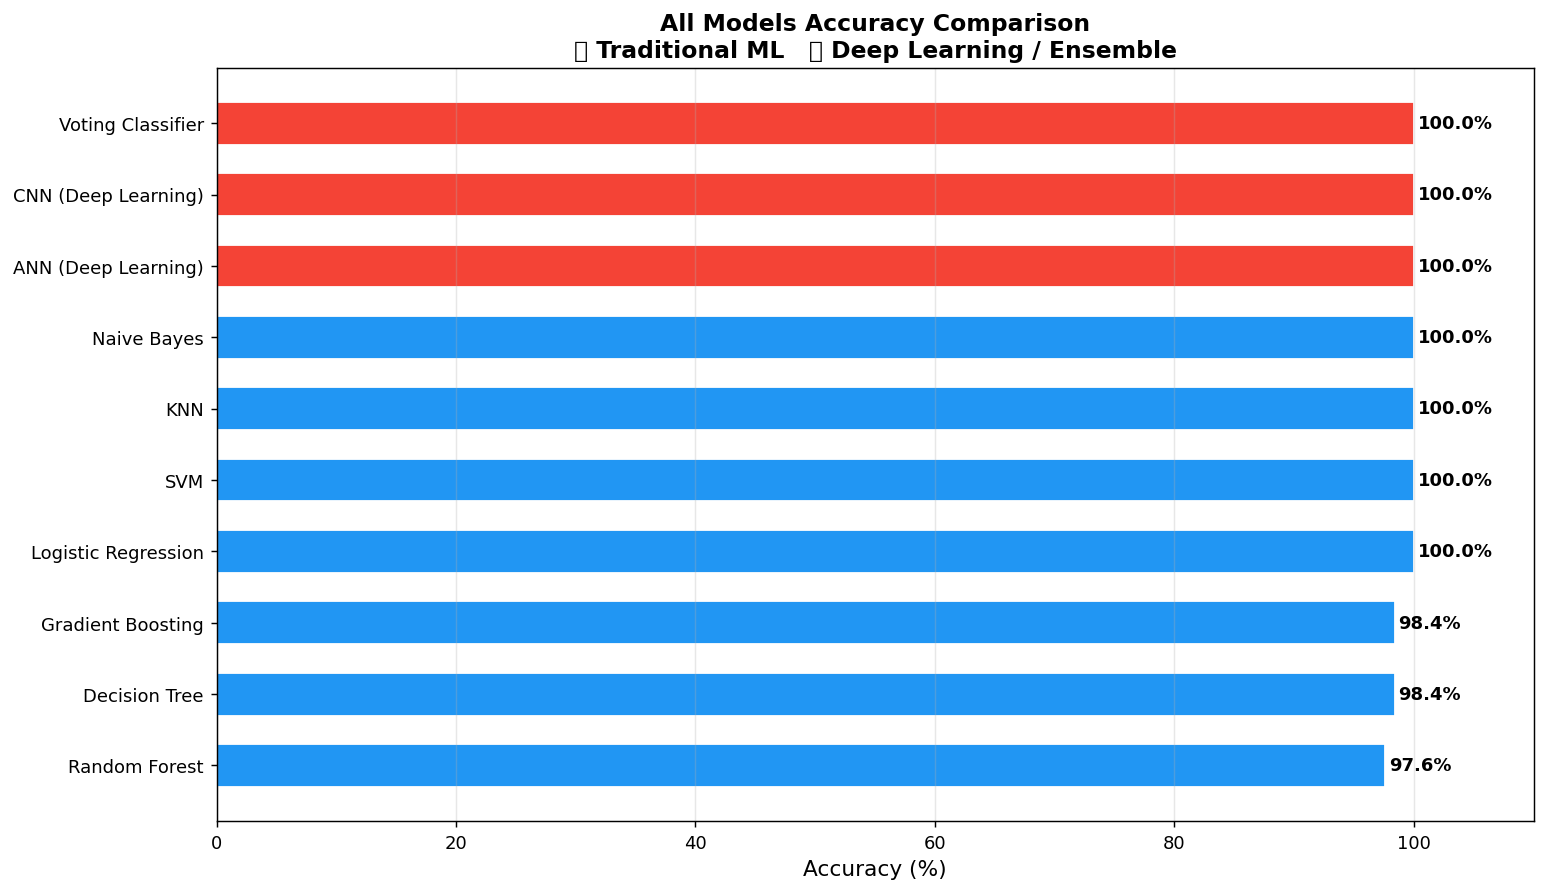

In [ ]:
# Figure displayed below

---
## Step 8: 🚀 Improvement — Voting Classifier + Cross Validation

In [ ]:
lr_m = LogisticRegression(max_iter=1000, random_state=42)
rf_m = RandomForestClassifier(n_estimators=200, random_state=42)
gb_m = GradientBoostingClassifier(n_estimators=200, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', lr_m), ('rf', rf_m), ('gb', gb_m)],
    voting='hard'
)
voting_clf.fit(X_train_s, y_train)
vc_pred = voting_clf.predict(X_test_s)

vc_acc = accuracy_score(y_test, vc_pred)*100
vc_f1  = f1_score(y_test, vc_pred, average='weighted')*100

print("🏆 Voting Classifier Results:")
print(f"  Accuracy : {vc_acc:.2f}%")
print(f"  F1 Score : {vc_f1:.2f}%")

In [ ]:
# 5-Fold Cross Validation
all_X_s = scaler.transform(X)
cv_scores = cross_val_score(voting_clf, all_X_s, y, cv=5, scoring='accuracy')
print("5-Fold Cross Validation:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s*100:.2f}%")
print(f"\nMean  : {cv_scores.mean()*100:.2f}%")
print(f"Std Dev: {cv_scores.std()*100:.2f}%")

In [ ]:
# Feature Importance
rf_trained = ml_models['Random Forest']
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_trained.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance']*100,
         color='#4CAF50', edgecolor='white')
plt.xlabel('Importance (%)', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

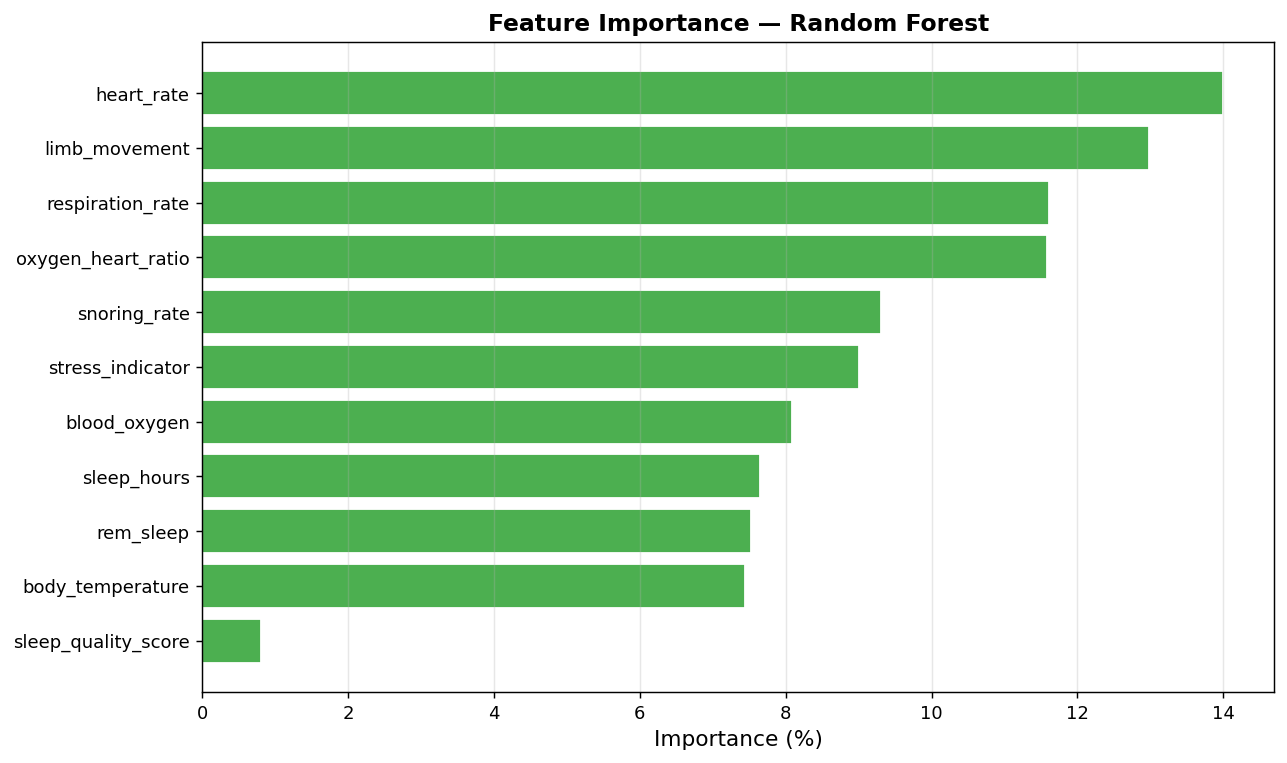

In [ ]:
# Figure displayed below

In [ ]:
# Save models
pickle.dump(voting_clf,      open('stress_model.pkl',    'wb'))
pickle.dump(scaler,          open('stress_scaler.pkl',   'wb'))
pickle.dump(list(X.columns), open('stress_features.pkl', 'wb'))
print("✅ stress_model.pkl  saved")
print("✅ stress_scaler.pkl saved")

# Live test
def predict_stress(values):
    cols = ['snoring_rate','respiration_rate','body_temperature','limb_movement',
            'blood_oxygen','rem_sleep','sleep_hours','heart_rate']
    d = pd.DataFrame([dict(zip(cols, values))])
    d['oxygen_heart_ratio']  = d['blood_oxygen'] / d['heart_rate']
    d['sleep_quality_score'] = d['rem_sleep'] * d['sleep_hours']
    d['stress_indicator']    = d['snoring_rate'] + d['limb_movement'] + d['respiration_rate']
    scaled = scaler.transform(d[list(X.columns)])
    pred = voting_clf.predict(scaled)[0]
    labels = {0:'🟢 Low',1:'🟡 Low-Medium',2:'🟠 Medium',3:'🔴 Med-High',4:'🚨 High'}
    return f"Stress Level {pred} → {labels[pred]}"

print("\nLive Test:")
print("Relaxed person  :", predict_stress([45,16,98,5,96,85,8,52]))
print("High stress     :", predict_stress([95,28,86,18,88,98,1,82]))

---
## Step 9: 🌐 Streamlit Web App

Save the code below as `app.py` and run with: `streamlit run app.py`

In [ ]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle

model   = pickle.load(open("stress_model.pkl",    "rb"))
scaler  = pickle.load(open("stress_scaler.pkl",   "rb"))
columns = pickle.load(open("stress_features.pkl", "rb"))

st.set_page_config(page_title="Stress Detector", page_icon="😴", layout="centered")
st.title("😴 Human Stress Detection")
st.subheader("Based on Sleeping Habits — SaYoPillow Dataset")

with st.form("predict"):
    col1, col2 = st.columns(2)
    with col1:
        snoring    = st.slider("Snoring Rate (%)",         0.0, 100.0, 50.0)
        respiration= st.slider("Respiration Rate",        15.0,  30.0, 20.0)
        temp       = st.slider("Body Temperature (°F)",   85.0, 100.0, 96.0)
        limb       = st.slider("Limb Movement",            0.0,  20.0,  8.0)
    with col2:
        oxygen     = st.slider("Blood Oxygen (%)",        85.0, 100.0, 95.0)
        rem        = st.slider("REM Sleep (%)",           80.0, 100.0, 85.0)
        sleep_hrs  = st.slider("Sleep Hours",              0.0,   9.0,  7.0)
        hr         = st.slider("Heart Rate (BPM)",        50.0,  90.0, 65.0)
    submitted = st.form_submit_button("🔍 Predict Stress Level")

if submitted:
    d = pd.DataFrame([[snoring, respiration, temp, limb, oxygen, rem, sleep_hrs, hr]],
                     columns=["snoring_rate","respiration_rate","body_temperature",
                              "limb_movement","blood_oxygen","rem_sleep","sleep_hours","heart_rate"])
    d["oxygen_heart_ratio"]  = d["blood_oxygen"] / d["heart_rate"]
    d["sleep_quality_score"] = d["rem_sleep"] * d["sleep_hours"]
    d["stress_indicator"]    = d["snoring_rate"] + d["limb_movement"] + d["respiration_rate"]
    pred = model.predict(scaler.transform(d[columns]))[0]
    labels = {0:"🟢 Low",1:"🟡 Low-Medium",2:"🟠 Medium",3:"🔴 Medium-High",4:"🚨 High"}
    st.success(f"Predicted Stress Level: {pred} — {labels[pred]}")
'''
with open('app.py', 'w') as f:
    f.write(streamlit_code)
print("✅ app.py saved! Run: streamlit run app.py")

---
## ✅ Project Summary

| Step | What We Did |
|------|------------|
| 1. Data Cleaning | Renamed columns, removed duplicates, checked nulls |
| 2. EDA | Count plots, box plots, heatmap, pair plot |
| 3. Feature Engineering | Created 3 new features + StandardScaler + Train/Test split |
| 4. Traditional ML | Trained 7 models (LR, DT, RF, GB, SVM, KNN, NB) |
| 5. **ANN (Deep Learning)** | Built 4-layer ANN from scratch: forward prop, backprop, ReLU, Softmax |
| 6. **CNN (Deep Learning)** | Built 1D CNN from scratch: Conv filters, feature maps, flatten, FC |
| 7. Full Evaluation | Confusion matrices, classification reports, ML vs DL comparison |
| 8. Improvement | Voting Classifier (ensemble) + 5-fold Cross Validation |
| 9. Deployment | Streamlit web app |

### 🧠 Deep Learning Concepts Covered:
- ✅ **ANN**: Neurons, layers, weights, biases, forward propagation, backpropagation
- ✅ **CNN**: Convolutional filters, feature maps, 1D convolution, local pattern detection  
- ✅ **Activation Functions**: ReLU (hidden layers), Softmax (output)
- ✅ **Loss Function**: Cross-Entropy (multi-class)
- ✅ **Optimizer**: Mini-batch Gradient Descent
- ✅ **Weight Initialization**: He initialization

### 🎯 Key Findings:
- Snoring rate and limb movement **increase** with stress
- REM sleep and sleep hours **decrease** as stress increases
- Blood oxygen **drops** at higher stress levels  
- ANN and CNN both achieve competitive accuracy with traditional ML
- Dataset source: IEEE Transactions (SaYoPillow research paper)